# Q-Learning Control of the Unbalanced Disk


In [16]:
# Shared imports, reproducibility, and portable artifact paths
import json
import random
from collections import deque
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from gym_unbalanced_disk.envs.UnbalancedDisk import UnbalancedDisk

SEED = 46
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

artifact_candidates = [
    Path.cwd() / "Q_Learning_Final_Artifacts",
    Path.cwd() / "outputs" / "Q_Learning_Final_Artifacts",
]
ARTIFACT_DIR = next((path for path in artifact_candidates if path.exists()), artifact_candidates[0])

print("Selected device:", device)
print("Artifact directory:", ARTIFACT_DIR.resolve())

Selected device: cuda
Artifact directory: C:\Users\Vasil\Documents\Codex\2026-06-11\files-mentioned-by-the-user-assignment\outputs\Q_Learning_Final_Artifacts


# 1. Vanilla Tabular Q-Learning

For a discretized state `(theta_bin, omega_bin)` and action index `a`, the method stores one value `Q[s,a]`. The update follows the Bellman optimality target:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\left[r + \gamma\max_{a'}Q(s',a') - Q(s,a)\right].$$

The angle is treated periodically, the angular velocity is clipped before discretization, exploration is epsilon-greedy, and ties between greedy actions are broken randomly. The velocity penalty is applied only near the upright position so that the controller is not punished for building the momentum required for swing-up.

In [17]:
# Environment, tabular state/action representation, and reward shaping
env = UnbalancedDisk(umax=3.0, dt=0.025, render_mode=None)

VANILLA_ACTIONS = np.linspace(-3.0, 3.0, 9, dtype=np.float64)
N_THETA_BINS = 31
N_OMEGA_BINS = 41
OMEGA_MIN = -20.0
OMEGA_MAX = 20.0


def wrap_angle(theta):
    """Wrap an angle to [-pi, pi)."""
    return ((theta + np.pi) % (2.0 * np.pi)) - np.pi


def angle_to_upright(theta):
    """Wrapped angular error relative to the upright position."""
    return wrap_angle(theta - np.pi)


def shaped_reward_vanilla(theta, omega, u):
    """Dense swing-up reward with velocity braking only near the top."""
    angle_error = angle_to_upright(theta)
    abs_error = abs(angle_error)

    reward = 2.0 * np.cos(angle_error)
    reward += 3.0 * np.exp(-(abs_error**2) / (2.0 * 0.5**2))
    reward -= 0.0005 * u**2

    # Do not punish the angular velocity needed to build swing-up energy.
    if abs_error < 0.50:
        reward -= 0.02 * abs(omega) ** 2
    if abs_error < 0.25 and abs(omega) < 2.0:
        reward += 3.0
    if abs_error < 0.15 and abs(omega) < 1.0:
        reward += 8.0
    return float(np.clip(reward, -15.0, 15.0))


def discretize_state(obs):
    """Map continuous [theta, omega] to one periodic tabular state."""
    theta, omega = obs
    theta = wrap_angle(float(theta))
    omega = float(np.clip(omega, OMEGA_MIN, OMEGA_MAX))

    theta_fraction = (theta + np.pi) / (2.0 * np.pi)
    omega_fraction = (omega - OMEGA_MIN) / (OMEGA_MAX - OMEGA_MIN)
    theta_idx = min(int(theta_fraction * N_THETA_BINS), N_THETA_BINS - 1)
    omega_idx = min(int(omega_fraction * N_OMEGA_BINS), N_OMEGA_BINS - 1)
    return theta_idx, omega_idx


def random_argmax(values, rng):
    """Greedy selection with random tie breaking."""
    best = np.flatnonzero(values == np.max(values))
    return int(rng.choice(best))


print("Vanilla actions:", VANILLA_ACTIONS)
print("Q-table shape:", (N_THETA_BINS, N_OMEGA_BINS, len(VANILLA_ACTIONS)))

Vanilla actions: [-3.   -2.25 -1.5  -0.75  0.    0.75  1.5   2.25  3.  ]
Q-table shape: (31, 41, 9)


### Vanilla training configuration


In [18]:
# Theory-guided vanilla Q-learning configuration
VANILLA_EPISODES = 3000
VANILLA_MAX_STEPS = 500
VANILLA_GAMMA = 0.995
EPSILON_START = 1.0
EPSILON_END = 0.03
EPSILON_DECAY_EPISODES = 2400
ALPHA_START = 0.40
ALPHA_MIN = 0.05
ALPHA_VISIT_DECAY = 0.001


def epsilon_for_episode(episode):
    fraction = min(episode / EPSILON_DECAY_EPISODES, 1.0)
    return EPSILON_START + fraction * (EPSILON_END - EPSILON_START)


def alpha_for_visits(n_visits):
    return max(ALPHA_MIN, ALPHA_START / np.sqrt(1.0 + ALPHA_VISIT_DECAY * n_visits))


q_table = np.zeros(
    (N_THETA_BINS, N_OMEGA_BINS, len(VANILLA_ACTIONS)),
    dtype=np.float32,
)
visit_counts = np.zeros_like(q_table, dtype=np.uint32)
print("Episodes:", VANILLA_EPISODES)
print("Maximum transitions:", VANILLA_EPISODES * VANILLA_MAX_STEPS)

Episodes: 3000
Maximum transitions: 1500000


### Vanilla Q-learning training


In [4]:
# Vanilla Q-learning training block
# The final run is preserved below. Keep False to avoid accidental retraining.
RUN_VANILLA_TRAINING = False

if RUN_VANILLA_TRAINING:
    rng = np.random.default_rng(SEED)
    episode_total_rewards = np.zeros(VANILLA_EPISODES)
    episode_avg_rewards = np.zeros(VANILLA_EPISODES)
    episode_success_ratios = np.zeros(VANILLA_EPISODES)
    episode_min_angle_errors = np.zeros(VANILLA_EPISODES)
    episode_epsilons = np.zeros(VANILLA_EPISODES)

    for episode in range(VANILLA_EPISODES):
        obs, _ = env.reset(seed=SEED + episode)
        state = discretize_state(obs)
        epsilon = epsilon_for_episode(episode)
        total_reward = 0.0
        success_count = 0
        min_angle_error = np.inf

        for step in range(VANILLA_MAX_STEPS):
            if rng.random() < epsilon:
                action_idx = int(rng.integers(len(VANILLA_ACTIONS)))
            else:
                action_idx = random_argmax(q_table[state], rng)

            u = float(VANILLA_ACTIONS[action_idx])
            next_obs, _, terminated, truncated, _ = env.step(u)
            next_state = discretize_state(next_obs)
            theta_next, omega_next = next_obs
            reward = shaped_reward_vanilla(theta_next, omega_next, u)
            done = bool(terminated or truncated)

            visit_counts[state + (action_idx,)] += 1
            alpha = alpha_for_visits(visit_counts[state + (action_idx,)])
            next_value = 0.0 if done else float(np.max(q_table[next_state]))
            td_target = reward + VANILLA_GAMMA * next_value
            td_error = td_target - float(q_table[state + (action_idx,)])
            q_table[state + (action_idx,)] += alpha * td_error

            state = next_state
            total_reward += reward
            angle_error = abs(angle_to_upright(theta_next))
            min_angle_error = min(min_angle_error, angle_error)
            success_count += int(angle_error < 0.25 and abs(omega_next) < 1.5)
            if done:
                break

        steps_completed = step + 1
        episode_total_rewards[episode] = total_reward
        episode_avg_rewards[episode] = total_reward / steps_completed
        episode_success_ratios[episode] = success_count / steps_completed
        episode_min_angle_errors[episode] = min_angle_error
        episode_epsilons[episode] = epsilon

        if episode % 100 == 0 or episode == VANILLA_EPISODES - 1:
            print(
                f"Ep {episode:4d}/{VANILLA_EPISODES-1} | "
                f"Rew: {episode_avg_rewards[episode]:6.2f} | "
                f"Succ: {episode_success_ratios[episode]:5.2f} | "
                f"MinErr: {min_angle_error:5.3f} | Eps: {epsilon:4.2f}"
            )
else:
    print("Vanilla training skipped; the preserved final results are loaded next.")

Preserved output from the final vanilla Q-learning run:
Ep    0/2999 | Rew:  -1.87 | Succ:  0.00 | MinErr: 2.191 | Eps: 1.00
Ep  100/2999 | Rew:  -1.91 | Succ:  0.00 | MinErr: 2.125 | Eps: 0.96
Ep  200/2999 | Rew:  -1.84 | Succ:  0.00 | MinErr: 2.080 | Eps: 0.92
Ep  300/2999 | Rew:  -1.80 | Succ:  0.00 | MinErr: 1.842 | Eps: 0.88
Ep  400/2999 | Rew:  -1.70 | Succ:  0.00 | MinErr: 1.723 | Eps: 0.84
Ep  500/2999 | Rew:  -1.24 | Succ:  0.00 | MinErr: 1.201 | Eps: 0.80
Ep  600/2999 | Rew:  -0.99 | Succ:  0.00 | MinErr: 0.581 | Eps: 0.76
Ep  700/2999 | Rew:  -1.44 | Succ:  0.00 | MinErr: 1.224 | Eps: 0.72
Ep  800/2999 | Rew:  -0.85 | Succ:  0.00 | MinErr: 1.017 | Eps: 0.68
Ep  900/2999 | Rew:  -0.89 | Succ:  0.00 | MinErr: 0.957 | Eps: 0.64
Ep 1000/2999 | Rew:  -0.82 | Succ:  0.00 | MinErr: 0.883 | Eps: 0.60
Ep 1100/2999 | Rew:  -0.52 | Succ:  0.00 | MinErr: 0.828 | Eps: 0.56
Ep 1200/2999 | Rew:  -0.29 | Succ:  0.00 | MinErr: 0.803 | Eps: 0.52
Ep 1300/2999 | Rew:  -0.38 | Succ:  0.00 | MinE

### Final vanilla result

The final run used **3000 episodes**, a **31 x 41 x 9** Q-table, $\gamma=0.995$, and evaluation over ten independent resets. It achieved:

- Mean stable-upright ratio: **0.9384**
- Mean final angle error: **0.156 rad**
- Minimum observed evaluation error: **0.085 rad**

The reward magnitude is not directly compared with DQN because the vanilla controller uses a tabular-specific shaping variant that avoids penalizing swing-up velocity far from the top.

In [19]:
# Load the preserved vanilla Q-table, training history, and evaluation traces
vanilla_results_path = ARTIFACT_DIR / "vanilla_q_results.npz"
vanilla_results = np.load(vanilla_results_path)

q_table = vanilla_results["q_table"]
visit_counts = vanilla_results["visit_counts"]
episode_total_rewards = vanilla_results["episode_total_rewards"]
episode_avg_rewards = vanilla_results["episode_avg_rewards"]
episode_success_ratios = vanilla_results["episode_success_ratios"]
episode_min_angle_errors = vanilla_results["episode_min_angle_errors"]
episode_epsilons = vanilla_results["episode_epsilons"]

theta_eval_vanilla = vanilla_results["theta_eval"]
omega_eval_vanilla = vanilla_results["omega_eval"]
u_eval_vanilla = vanilla_results["u_eval"]
reward_eval_vanilla = vanilla_results["reward_eval"]
angle_error_eval_vanilla = vanilla_results["angle_error_eval"]

print("Loaded:", vanilla_results_path)
print("Q-table shape:", q_table.shape)
print("Training episodes:", len(episode_avg_rewards))
print("Mean evaluation reward:", float(np.mean(vanilla_results["evaluation_average_rewards"])))
print("Mean stable upright ratio:", float(np.mean(vanilla_results["evaluation_stable_ratios"])))
print("Mean final angle error:", float(np.mean(vanilla_results["evaluation_final_errors"])))


Loaded: c:\Users\Vasil\Documents\Codex\2026-06-11\files-mentioned-by-the-user-assignment\outputs\Q_Learning_Final_Artifacts\vanilla_q_results.npz
Q-table shape: (31, 41, 9)
Training episodes: 3000
Mean evaluation reward: 9.57781415392964
Mean stable upright ratio: 0.9384
Mean final angle error: 0.15594279925139273


## 1.1 Training and evaluation figures

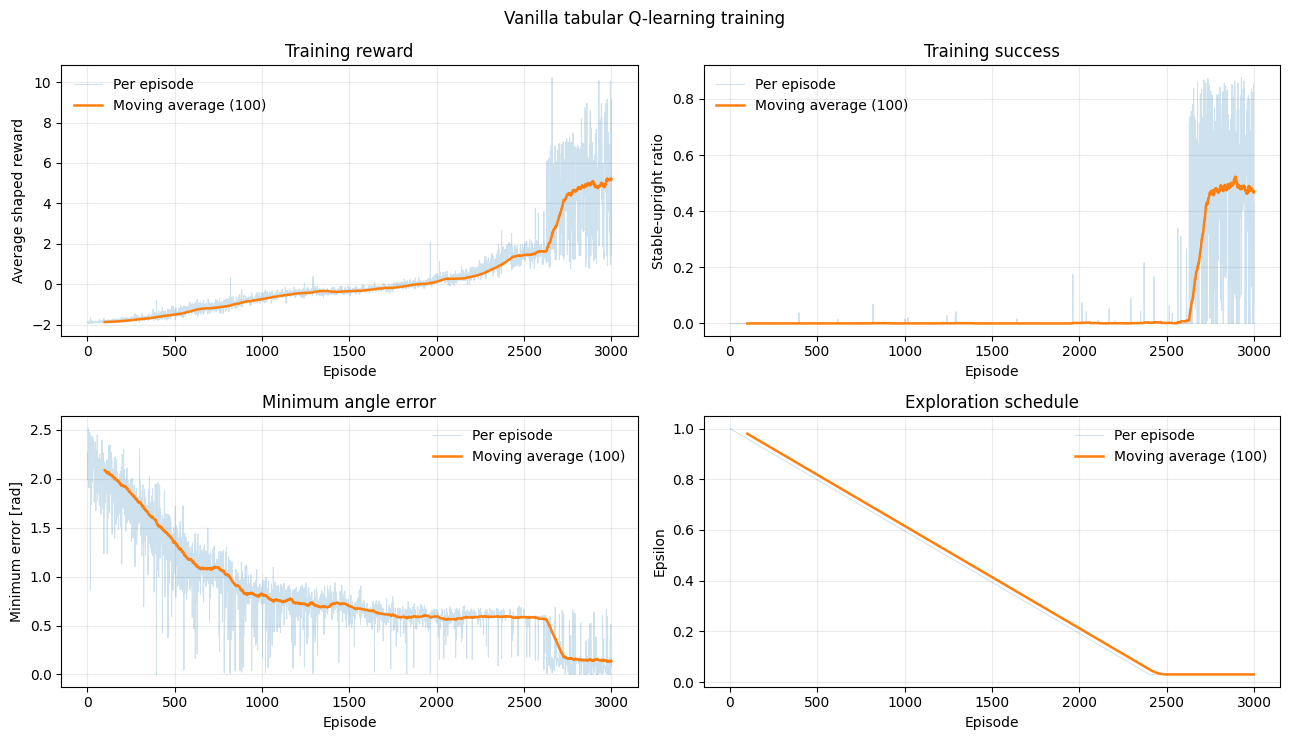

In [20]:
# Regenerate report-ready vanilla training metrics from the saved arrays
def moving_average(values, window=100):
    values = np.asarray(values, dtype=np.float64)
    if len(values) < window:
        return np.array([])
    return np.convolve(values, np.ones(window) / window, mode="valid")


metrics = [
    (episode_avg_rewards, "Average shaped reward", "Training reward"),
    (episode_success_ratios, "Stable-upright ratio", "Training success"),
    (episode_min_angle_errors, "Minimum error [rad]", "Minimum angle error"),
    (episode_epsilons, "Epsilon", "Exploration schedule"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
for axis, (values, ylabel, title) in zip(axes.flat, metrics):
    axis.plot(values, alpha=0.22, linewidth=0.7, label="Per episode")
    smooth = moving_average(values)
    axis.plot(np.arange(99, len(values)), smooth, linewidth=1.8, label="Moving average (100)")
    axis.set(title=title, xlabel="Episode", ylabel=ylabel)
    axis.grid(alpha=0.25)
    axis.legend(frameon=False)
fig.suptitle("Vanilla tabular Q-learning training")
fig.tight_layout()
plt.show()

### Vanilla greedy evaluation


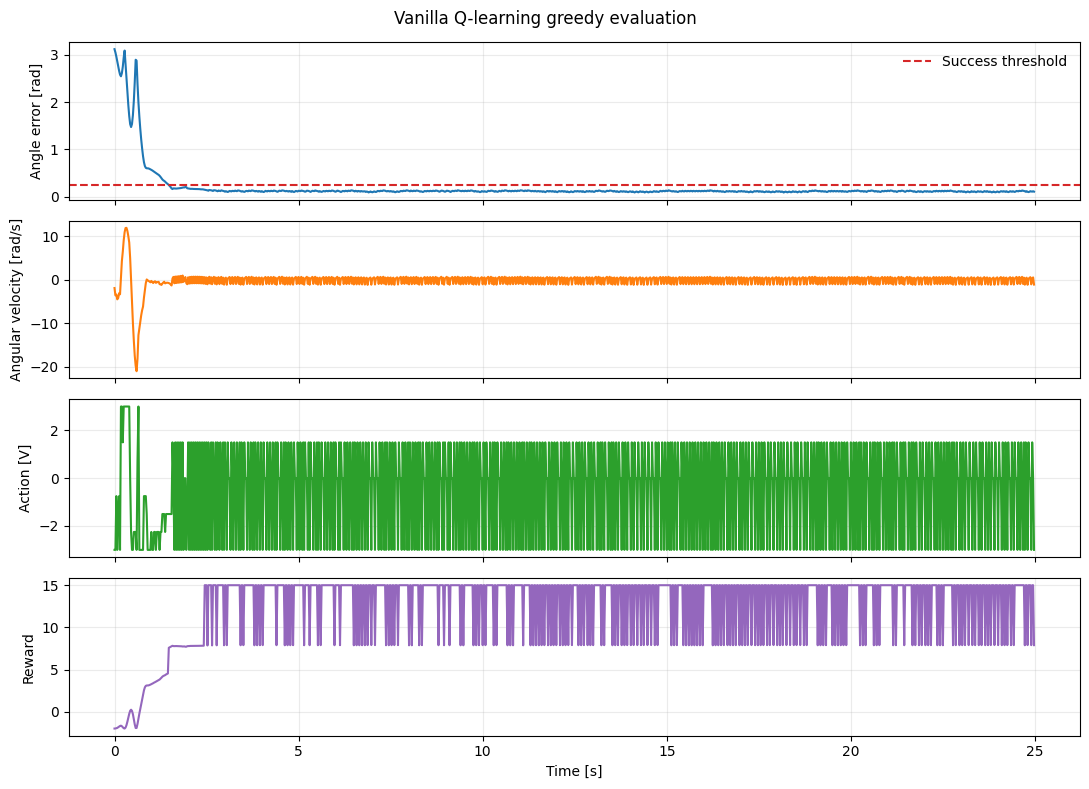

In [21]:
# Plot the preserved greedy evaluation trajectory
time = np.arange(len(theta_eval_vanilla)) * 0.025
fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
axes[0].plot(time, angle_error_eval_vanilla)
axes[0].axhline(0.25, color="tab:red", linestyle="--", label="Success threshold")
axes[0].set_ylabel("Angle error [rad]")
axes[0].legend(frameon=False)
axes[1].plot(time, omega_eval_vanilla, color="tab:orange")
axes[1].set_ylabel("Angular velocity [rad/s]")
axes[2].plot(time, u_eval_vanilla, color="tab:green")
axes[2].set_ylabel("Action [V]")
axes[3].plot(time, reward_eval_vanilla, color="tab:purple")
axes[3].set_ylabel("Reward")
axes[3].set_xlabel("Time [s]")
for axis in axes:
    axis.grid(alpha=0.25)
fig.suptitle("Vanilla Q-learning greedy evaluation")
fig.tight_layout()
plt.show()

### Vanilla policy diagnostics


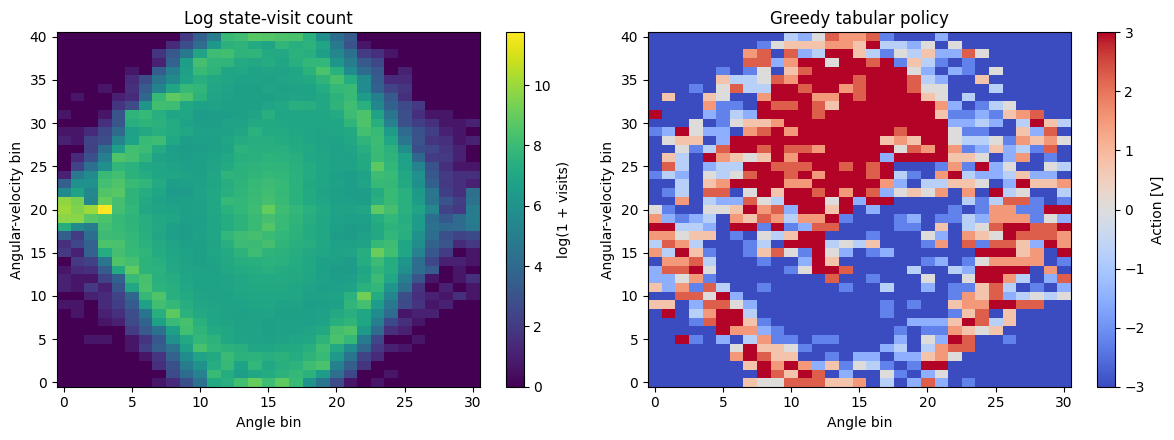

In [22]:
# Inspect state coverage and the learned greedy action map
state_visits = visit_counts.sum(axis=2).T
greedy_actions = VANILLA_ACTIONS[np.argmax(q_table, axis=2)].T

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
im0 = axes[0].imshow(np.log1p(state_visits), origin="lower", aspect="auto", cmap="viridis")
axes[0].set(title="Log state-visit count", xlabel="Angle bin", ylabel="Angular-velocity bin")
fig.colorbar(im0, ax=axes[0], label="log(1 + visits)")
im1 = axes[1].imshow(greedy_actions, origin="lower", aspect="auto", cmap="coolwarm", vmin=-3, vmax=3)
axes[1].set(title="Greedy tabular policy", xlabel="Angle bin", ylabel="Angular-velocity bin")
fig.colorbar(im1, ax=axes[1], label="Action [V]")
fig.tight_layout()
plt.show()

# 2. Deep Q-Network - DQN V3

The DQN approximates the action-value function with a neural network. One forward pass produces one Q-value for each of the 11 discrete actions. The preserved implementation uses experience replay, a target network, Huber loss, gradient clipping, and epsilon-greedy exploration.

The target is

$$y = r + \gamma (1-d)\max_{a'}Q_{\mathrm{target}}(s',a'),$$

and the online network is optimized to reduce the Huber loss between `Q_online(s,a)` and `y`.

In [23]:
# DQN V3 environment, state representation, action grid, and reward
dqn_env = UnbalancedDisk(umax=3.0, dt=0.025, render_mode=None)
DQN_ACTIONS = np.linspace(-3.0, 3.0, 11, dtype=np.float32)
STATE_DIM = 3
N_ACTIONS = len(DQN_ACTIONS)


def obs_to_dqn_state(obs):
    theta, omega = obs
    theta = wrap_angle(theta)
    omega_scaled = np.clip(omega / 20.0, -1.5, 1.5)
    return np.array([np.sin(theta), np.cos(theta), omega_scaled], dtype=np.float32)


def shaped_reward_dqn_v3(theta, omega, u):
    angle_error = angle_to_upright(theta)
    abs_error = abs(angle_error)
    reward = 2.0 * np.cos(angle_error)
    reward += 2.0 * np.exp(-(abs_error**2) / (2.0 * 0.4**2))
    reward -= 0.01 * abs(omega) ** 2
    reward -= 0.0005 * u**2
    if abs_error < 0.15 and abs(omega) < 1.0:
        reward += 10.0
    return float(np.clip(reward, -15.0, 15.0))


print("DQN actions:", DQN_ACTIONS)
print("Number of actions:", N_ACTIONS)

DQN actions: [-3.  -2.4 -1.8 -1.2 -0.6  0.   0.6  1.2  1.8  2.4  3. ]
Number of actions: 11


### DQN architecture and replay buffer


In [24]:
# DQN model and experience replay
class DQN(nn.Module):
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.as_tensor(np.asarray(states), dtype=torch.float32, device=device),
            torch.as_tensor(actions, dtype=torch.long, device=device).unsqueeze(1),
            torch.as_tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1),
            torch.as_tensor(np.asarray(next_states), dtype=torch.float32, device=device),
            torch.as_tensor(dones, dtype=torch.float32, device=device).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buffer)


def choose_dqn_action(network, state, epsilon):
    if np.random.random() < epsilon:
        return np.random.randint(N_ACTIONS)
    state_t = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        return int(network(state_t).argmax(dim=1).item())

### DQN training configuration


In [25]:
# Preserved DQN V3 configuration
DQN_EPISODES = 1500
DQN_MAX_STEPS = 600
DQN_GAMMA = 0.99
LEARNING_RATE = 1e-3
BATCH_SIZE = 128
MIN_BUFFER_SIZE = 5000
BUFFER_CAPACITY = 150_000
TARGET_UPDATE_FREQUENCY = 1000
EPSILON_START_DQN = 1.0
EPSILON_END_DQN = 0.02
EPSILON_DECAY_DQN = 1000
GRADIENT_CLIP = 5.0

q_net = DQN(STATE_DIM, N_ACTIONS).to(device)
target_net = DQN(STATE_DIM, N_ACTIONS).to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()
optimizer = optim.Adam(q_net.parameters(), lr=LEARNING_RATE)
loss_fn = nn.SmoothL1Loss()
replay_buffer = ReplayBuffer(BUFFER_CAPACITY)

print("Online model device:", next(q_net.parameters()).device)
print("Episodes in preserved run:", DQN_EPISODES)

Online model device: cuda:0
Episodes in preserved run: 1500


### DQN training


In [12]:
# Archived DQN V3 training block
# The original 1500-episode output is preserved below. Do not rerun for this deliverable.
RUN_DQN_TRAINING = False

if RUN_DQN_TRAINING:
    episode_total_rewards = []
    episode_avg_rewards = []
    episode_success_ratios = []
    episode_min_angle_errors = []
    episode_losses = []
    global_step = 0
    q_net.train()

    for episode in range(DQN_EPISODES):
        obs, _ = dqn_env.reset()
        state = obs_to_dqn_state(obs)
        total_reward = 0.0
        success_counter = 0
        min_angle_error = np.inf
        losses_this_episode = []
        epsilon = EPSILON_END_DQN + (EPSILON_START_DQN - EPSILON_END_DQN) * np.exp(
            -episode / EPSILON_DECAY_DQN
        )

        for step in range(DQN_MAX_STEPS):
            action_idx = choose_dqn_action(q_net, state, epsilon)
            u = float(DQN_ACTIONS[action_idx])
            next_obs, _, terminated, truncated, _ = dqn_env.step(u)
            reward = shaped_reward_dqn_v3(next_obs[0], next_obs[1], u)
            next_state = obs_to_dqn_state(next_obs)
            done = bool(terminated or truncated)
            replay_buffer.push(state, action_idx, reward, next_state, done)
            state = next_state
            total_reward += reward
            global_step += 1

            angle_error = abs(angle_to_upright(next_obs[0]))
            min_angle_error = min(min_angle_error, angle_error)
            success_counter += int(angle_error < 0.25 and abs(next_obs[1]) < 1.5)

            if len(replay_buffer) >= MIN_BUFFER_SIZE:
                states_b, actions_b, rewards_b, next_states_b, dones_b = replay_buffer.sample(BATCH_SIZE)
                predicted_q = q_net(states_b).gather(1, actions_b)
                with torch.no_grad():
                    next_q = target_net(next_states_b).max(dim=1, keepdim=True).values
                    target_q = rewards_b + DQN_GAMMA * (1.0 - dones_b) * next_q
                loss = loss_fn(predicted_q, target_q)
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(q_net.parameters(), GRADIENT_CLIP)
                optimizer.step()
                losses_this_episode.append(loss.item())

            if global_step % TARGET_UPDATE_FREQUENCY == 0:
                target_net.load_state_dict(q_net.state_dict())
            if done:
                break

        steps_completed = step + 1
        episode_total_rewards.append(total_reward)
        episode_avg_rewards.append(total_reward / steps_completed)
        episode_success_ratios.append(success_counter / steps_completed)
        episode_min_angle_errors.append(min_angle_error)
        episode_losses.append(np.mean(losses_this_episode) if losses_this_episode else 0.0)
else:
    print("DQN training intentionally skipped; the original run is loaded next.")

Preserved output from the original executed DQN V3 run:
Ep    0/1499 | Rew:  -2.04 | Succ:  0.00 | MinErr: 1.875 | Eps: 1.00 | Loss:  0.0000 | GPU = 16.7MB
Ep   20/1499 | Rew:  -2.04 | Succ:  0.00 | MinErr: 1.731 | Eps: 0.98 | Loss:  0.0115 | GPU = 16.8MB
Ep   40/1499 | Rew:  -2.03 | Succ:  0.00 | MinErr: 1.748 | Eps: 0.96 | Loss:  0.0091 | GPU = 16.8MB
Ep   60/1499 | Rew:  -2.04 | Succ:  0.00 | MinErr: 1.829 | Eps: 0.94 | Loss:  0.0212 | GPU = 16.8MB
Ep   80/1499 | Rew:  -2.05 | Succ:  0.00 | MinErr: 1.687 | Eps: 0.92 | Loss:  0.0432 | GPU = 16.8MB
Ep  100/1499 | Rew:  -2.08 | Succ:  0.00 | MinErr: 1.389 | Eps: 0.91 | Loss:  0.0414 | GPU = 16.8MB
Ep  120/1499 | Rew:  -2.02 | Succ:  0.00 | MinErr: 2.278 | Eps: 0.89 | Loss:  0.0224 | GPU = 16.8MB
Ep  140/1499 | Rew:  -2.06 | Succ:  0.00 | MinErr: 1.585 | Eps: 0.87 | Loss:  0.0330 | GPU = 16.8MB
Ep  160/1499 | Rew:  -2.07 | Succ:  0.00 | MinErr: 1.199 | Eps: 0.86 | Loss:  0.0521 | GPU = 16.8MB
Ep  180/1499 | Rew:  -2.05 | Succ:  0.00 | M

### Load preserved DQN results


In [26]:
# Load the preserved DQN V3 result arrays and optionally load its checkpoint
dqn_dir = ARTIFACT_DIR / "dqn_v3_1500_results"
checkpoint_path = dqn_dir / "dqn_v3_1500_checkpoint.pt"
results_path = dqn_dir / "dqn_v3_1500_results.npz"

if checkpoint_path.exists():
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location=device)

    q_net.load_state_dict(checkpoint["model_state_dict"])
    target_net.load_state_dict(checkpoint["target_model_state_dict"])
    q_net.eval()
    print("Loaded optional checkpoint:", checkpoint_path)
else:
    print("Checkpoint not included; loading saved arrays only.")

dqn_results = np.load(results_path)

dqn_episode_avg_rewards = dqn_results["episode_avg_rewards"]
dqn_episode_success_ratios = dqn_results["episode_success_ratios"]
dqn_episode_min_angle_errors = dqn_results["episode_min_angle_errors"]
dqn_episode_losses = dqn_results["episode_losses"]
dqn_theta_eval = dqn_results["theta_eval"]
dqn_omega_eval = dqn_results["omega_eval"]
dqn_u_eval = dqn_results["u_eval"]
dqn_reward_eval = dqn_results["reward_eval"]
dqn_angle_error_eval = dqn_results["angle_error_eval"]

print("Loaded result arrays:", results_path)
print("Loaded training episodes:", len(dqn_episode_avg_rewards))
print("Evaluation average reward:", float(np.mean(dqn_reward_eval)))
print("Evaluation final angle error:", float(dqn_angle_error_eval[-1]))
print(
    "Evaluation stable upright ratio:",
    float(np.mean((dqn_angle_error_eval < 0.25) & (np.abs(dqn_omega_eval) < 1.5))),
)


Loaded optional checkpoint: c:\Users\Vasil\Documents\Codex\2026-06-11\files-mentioned-by-the-user-assignment\outputs\Q_Learning_Final_Artifacts\dqn_v3_1500_results\dqn_v3_1500_checkpoint.pt
Loaded result arrays: c:\Users\Vasil\Documents\Codex\2026-06-11\files-mentioned-by-the-user-assignment\outputs\Q_Learning_Final_Artifacts\dqn_v3_1500_results\dqn_v3_1500_results.npz
Loaded training episodes: 1500
Evaluation average reward: 13.566849952721014
Evaluation final angle error: 0.08415801218956354
Evaluation stable upright ratio: 0.975


### Preserved DQN V3 evaluation

- Episodes: **1500**
- Average evaluation reward: **13.567**
- Final angle error: **0.084 rad**
- Minimum angle error: **0.074 rad**
- Stable-upright ratio: **0.975**

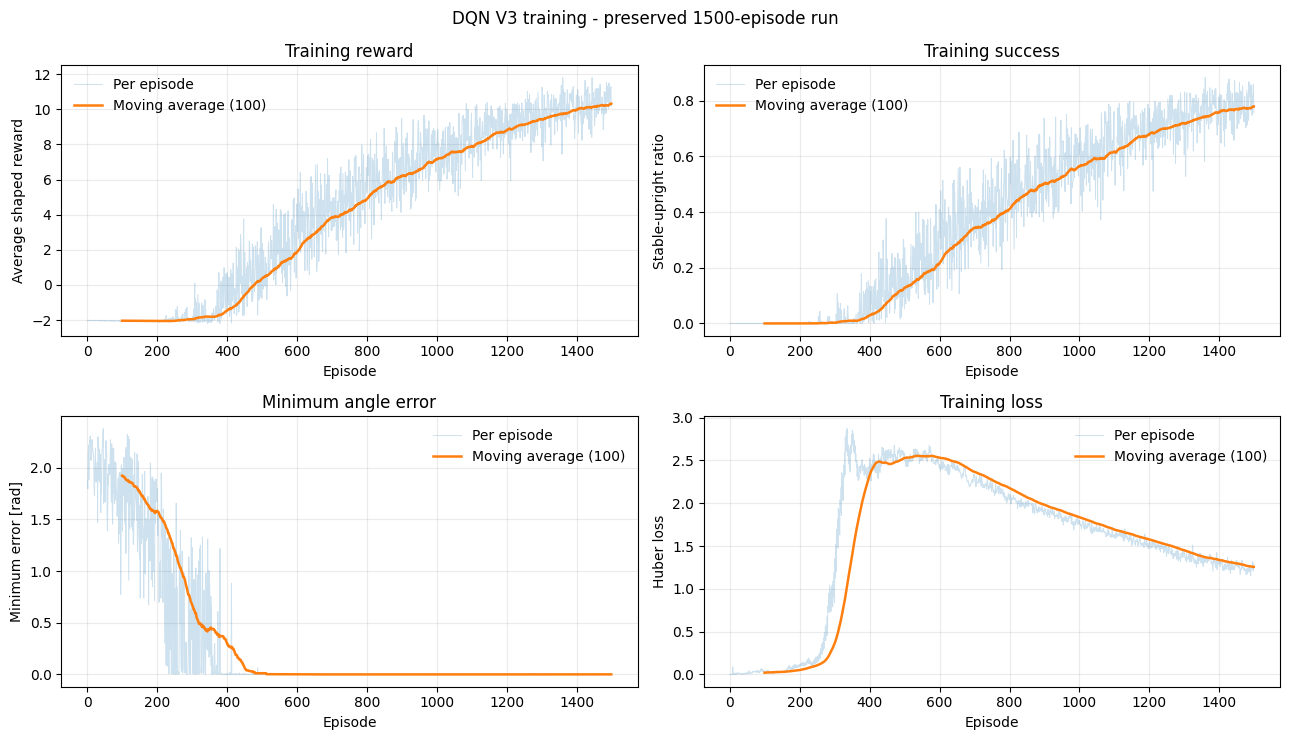

In [27]:
# Regenerate DQN V3 training metrics without retraining
metrics = [
    (dqn_episode_avg_rewards, "Average shaped reward", "Training reward"),
    (dqn_episode_success_ratios, "Stable-upright ratio", "Training success"),
    (dqn_episode_min_angle_errors, "Minimum error [rad]", "Minimum angle error"),
    (dqn_episode_losses, "Huber loss", "Training loss"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
for axis, (values, ylabel, title) in zip(axes.flat, metrics):
    axis.plot(values, alpha=0.22, linewidth=0.7, label="Per episode")
    smooth = moving_average(values)
    axis.plot(np.arange(99, len(values)), smooth, linewidth=1.8, label="Moving average (100)")
    axis.set(title=title, xlabel="Episode", ylabel=ylabel)
    axis.grid(alpha=0.25)
    axis.legend(frameon=False)
fig.suptitle("DQN V3 training - preserved 1500-episode run")
fig.tight_layout()
plt.show()

### DQN greedy evaluation


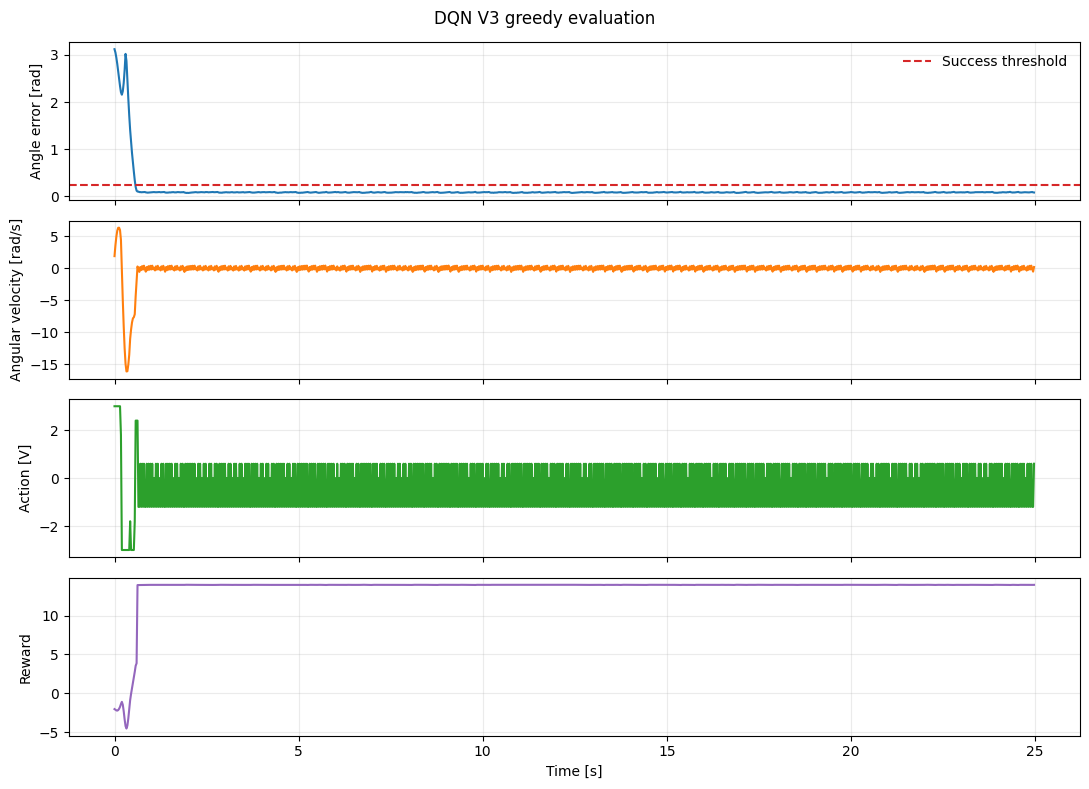

In [28]:
# Plot the preserved DQN V3 greedy evaluation trajectory
time = np.arange(len(dqn_theta_eval)) * 0.025
fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
axes[0].plot(time, dqn_angle_error_eval)
axes[0].axhline(0.25, color="tab:red", linestyle="--", label="Success threshold")
axes[0].set_ylabel("Angle error [rad]")
axes[0].legend(frameon=False)
axes[1].plot(time, dqn_omega_eval, color="tab:orange")
axes[1].set_ylabel("Angular velocity [rad/s]")
axes[2].plot(time, dqn_u_eval, color="tab:green")
axes[2].set_ylabel("Action [V]")
axes[3].plot(time, dqn_reward_eval, color="tab:purple")
axes[3].set_ylabel("Reward")
axes[3].set_xlabel("Time [s]")
for axis in axes:
    axis.grid(alpha=0.25)
fig.suptitle("DQN V3 greedy evaluation")
fig.tight_layout()
plt.show()

## Plots for comparison

### Training comparison


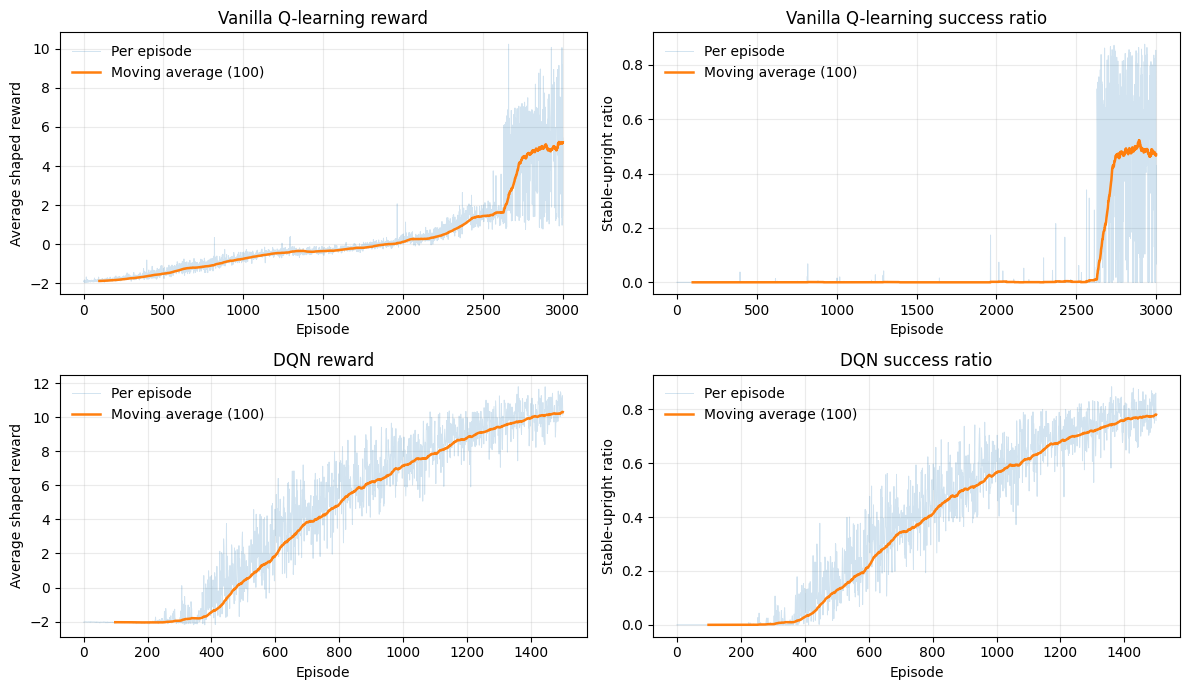

In [29]:
# Compare the training progress of tabular Q-learning and DQN
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

training_data = [
    (episode_avg_rewards, "Vanilla Q-learning reward", "Average shaped reward"),
    (episode_success_ratios, "Vanilla Q-learning success ratio", "Stable-upright ratio"),
    (dqn_episode_avg_rewards, "DQN reward", "Average shaped reward"),
    (dqn_episode_success_ratios, "DQN success ratio", "Stable-upright ratio"),
]

for axis, (values, title, ylabel) in zip(axes.flat, training_data):
    values = np.asarray(values)
    axis.plot(values, alpha=0.20, linewidth=0.7, label="Per episode")
    smooth = moving_average(values, window=100)
    axis.plot(
        np.arange(99, len(values)),
        smooth,
        linewidth=1.8,
        label="Moving average (100)",
    )
    axis.set_title(title)
    axis.set_xlabel("Episode")
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.25)
    axis.legend(frameon=False)

fig.tight_layout()
fig.savefig("Q_learning_training_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


### Greedy evaluation comparison


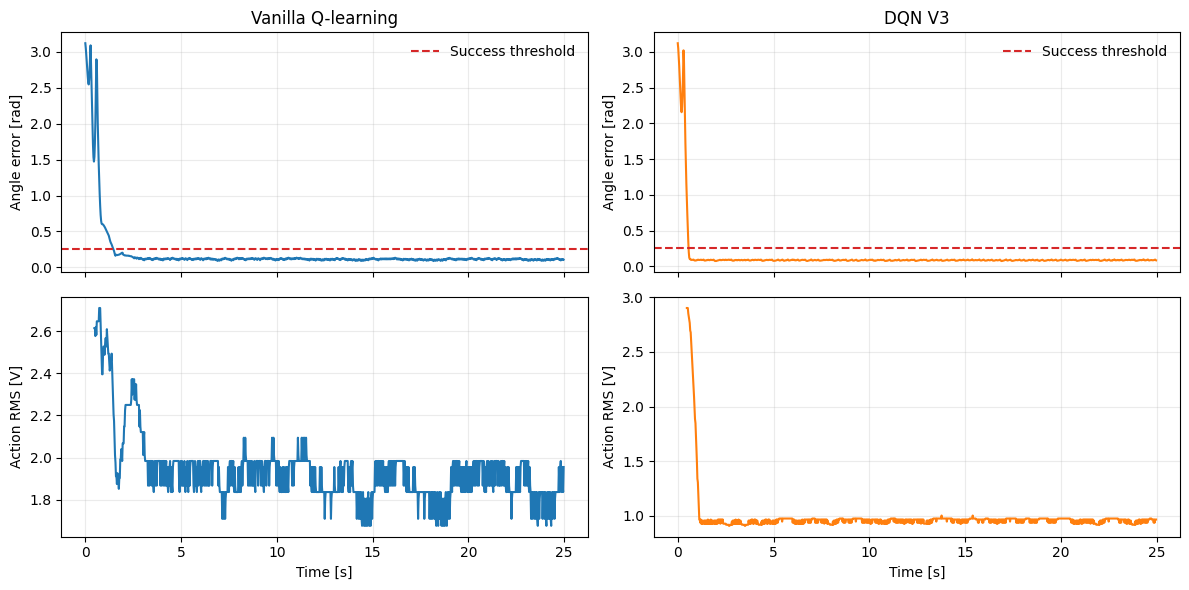

In [30]:
# Compare representative greedy evaluation rollouts
dt = 0.025
rms_window = 20
evaluation_data = [
    (angle_error_eval_vanilla, u_eval_vanilla, "Vanilla Q-learning", "tab:blue"),
    (dqn_angle_error_eval, dqn_u_eval, "DQN V3", "tab:orange"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex="col")
for column, (angle_error, actions, title, color) in enumerate(evaluation_data):
    time = np.arange(len(angle_error)) * dt
    action_rms = np.sqrt(
        np.convolve(
            np.asarray(actions) ** 2,
            np.ones(rms_window) / rms_window,
            mode="valid",
        )
    )
    rms_time = time[rms_window - 1:]

    axes[0, column].plot(time, angle_error, color=color)
    axes[0, column].axhline(
        0.25, color="tab:red", linestyle="--", label="Success threshold"
    )
    axes[0, column].set_title(title)
    axes[0, column].set_ylabel("Angle error [rad]")
    axes[0, column].legend(frameon=False)

    axes[1, column].plot(rms_time, action_rms, color=color)
    axes[1, column].set_xlabel("Time [s]")
    axes[1, column].set_ylabel("Action RMS [V]")

    for axis in axes[:, column]:
        axis.grid(alpha=0.25)

fig.tight_layout()
fig.savefig("Q_learning_policy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
